# RNA-seq DEG Analysis: DESeq2 vs Statistical Methods Comparison

In [1]:
#1 loading data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

counts = pd.read_csv(r"C:\Users\alfek\Desktop\Bioinformatics projects\Python\transciptomic analysis\Diabetes_infection_count.csv", index_col = 0)
meta = pd.read_csv(r"C:\Users\alfek\Desktop\Bioinformatics projects\Python\transciptomic analysis\Diabetes_infection_pheno.csv", index_col = 0)


In [2]:
print(counts.shape)
print(counts)
print(meta.shape)
print(meta)

(10346, 397)
          ZOQM06Q-1011  ZOBX723-1013  ZOBX723-1021  ZOBX723-1022  \
A1BG                11            20            36            19   
A1BG-AS1             4             8             4             3   
A1CF                 0             1             0             0   
A2M                140          1155          1297          1256   
A2M-AS1              0             2             0             0   
...                ...           ...           ...           ...   
ZXDB                 1             5             1             0   
ZXDC                 0             8             0             2   
ZYX                  4            16             4            17   
ZZEF1                0            15             5            18   
ZZZ3                 1             1             2             3   

          ZO94RDZ-1011  ZO5QFNX-1012  ZO5QFNX-1013  ZNQOVZV-02  ZNQOVZV-1011  \
A1BG                11            10            13          14             4   
A1BG-AS1  

In [3]:
#2 Cleaning and Filtering data
# Remove null values
counts = counts.fillna(0)

# Convert values to integers
counts = counts.astype(int)

# Filter low-count genes
counts_10 = counts[counts.mean(axis=1) > 10]

In [4]:
#3 Splitting samples by group
counts.columns == meta.index

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [5]:
print(counts.columns)
print(meta.index)

Index(['ZOQM06Q-1011', 'ZOBX723-1013', 'ZOBX723-1021', 'ZOBX723-1022',
       'ZO94RDZ-1011', 'ZO5QFNX-1012', 'ZO5QFNX-1013', 'ZNQOVZV-02',
       'ZNQOVZV-1011', 'ZNQOVZV-1012',
       ...
       'ZKFV71L-2011', 'ZKFV71L-6011', 'ZKFV71L-6021', 'ZK4CK8Y-07',
       'ZK4CK8Y-08', 'ZK4CK8Y-09', 'ZK4CK8Y-10', 'ZJXC41N-01', 'ZJXC41N-02',
       'ZJXC41N-11'],
      dtype='object', length=397)
Index(['ZOQM06Q.1011', 'ZOBX723.1013', 'ZOBX723.1021', 'ZOBX723.1022',
       'ZO94RDZ.1011', 'ZO5QFNX.1012', 'ZO5QFNX.1013', 'ZNQOVZV.02',
       'ZNQOVZV.1011', 'ZNQOVZV.1012',
       ...
       'ZKFV71L.2011', 'ZKFV71L.6011', 'ZKFV71L.6021', 'ZK4CK8Y.07',
       'ZK4CK8Y.08', 'ZK4CK8Y.09', 'ZK4CK8Y.10', 'ZJXC41N.01', 'ZJXC41N.02',
       'ZJXC41N.11'],
      dtype='object', name='SampleID', length=397)


In [6]:
print(meta['CL4'])

SampleID
ZOQM06Q.1011    Infection
ZOBX723.1013    Infection
ZOBX723.1021    Infection
ZOBX723.1022    Infection
ZO94RDZ.1011    Infection
                  ...    
ZK4CK8Y.09        Healthy
ZK4CK8Y.10        Healthy
ZJXC41N.01        Healthy
ZJXC41N.02        Healthy
ZJXC41N.11        Healthy
Name: CL4, Length: 397, dtype: object


In [7]:
meta.index = meta.index.str.replace(".", "-", regex=False)     # regex=false because The dot . has a special meaning in regex, it means "match any character". so we turn it off Since pandas' .str.replace() uses regex mode by default, you must pass regex=False whenever you're replacing characters that have special regex meaning  like ., +, *, (, )
meta["CL4"] = meta["CL4"].str.replace("Infection", "Infected", regex=False)

Healthy_samples  = meta[meta['CL4'] == 'Healthy'].index
Infected_samples = meta[meta['CL4'] == 'Infected'].index
print(Healthy_samples)
print(Infected_samples)
print(Healthy_samples.shape)
print(Infected_samples.shape)

Index(['ZOQM06Q-01', 'ZOQM06Q-02', 'ZOQM06Q-04', 'ZIS22OE-02', 'ZOBX723-03',
       'ZOBX723-05', 'ZOBX723-06', 'ZOBX723-07', 'ZO94RDZ-01', 'ZO94RDZ-05',
       ...
       'ZKFV71L-2011', 'ZKFV71L-6011', 'ZKFV71L-6021', 'ZK4CK8Y-07',
       'ZK4CK8Y-08', 'ZK4CK8Y-09', 'ZK4CK8Y-10', 'ZJXC41N-01', 'ZJXC41N-02',
       'ZJXC41N-11'],
      dtype='object', name='SampleID', length=332)
Index(['ZOQM06Q-1011', 'ZOBX723-1013', 'ZOBX723-1021', 'ZOBX723-1022',
       'ZO94RDZ-1011', 'ZO5QFNX-1012', 'ZO5QFNX-1013', 'ZNQOVZV-02',
       'ZNQOVZV-1011', 'ZNQOVZV-1012', 'ZN9YTFN-1011', 'ZN9YTFN-1012',
       'ZN9YTFN-1013', 'ZN3TBJM-1011', 'ZN3TBJM-1013', 'ZN3TBJM-1023',
       'ZMGT937-1011', 'ZMGT937-1012', 'ZMGT937-1013', 'ZMBVNFM-1012',
       'ZMBVNFM-1013', 'ZMBVNFM-1022', 'ZMBVNFM-1032', 'ZMBVNFM-1033',
       'ZLZNCLZ-1021', 'ZLZNCLZ-1023', 'ZLZNCLZ-1032', 'ZLZNCLZ-1033',
       'ZLYEM2C-1011', 'ZX52KVK-1011', 'ZX52KVK-1012', 'ZX52KVK-1021',
       'ZX52KVK-1022', 'ZX52KVK-1032', 'ZX52KVK-10

In [8]:
#4 Normalization by Log2 CPM 

cpm = counts_10.div(counts_10.sum(axis=0), axis=1) * 1e6


# Divide each gene's count by the total counts in its sample (library size),
# then multiply by 1e6 — this gives CPM (Counts Per Million),
# correcting for differences in sequencing depth between samples

log2_cpm = np.log2(cpm + 1)

# Add a pseudocount of 1 to avoid log2(0) = -inf for zero-count genes,
# then apply log2 transformation to compress the dynamic range,
# normalize the skewed distribution, and make fold-changes interpretable
# (a difference of 1 in log2 CPM = a 2x fold change)


print(log2_cpm)

#The result is a matrix that is comparable across samples and statistically well-behaved for clustering, PCA, and differential expression analysis.

            ZOQM06Q-1011  ZOBX723-1013  ZOBX723-1021  ZOBX723-1022  \
A1BG            6.327480      6.647227      7.622657      6.667027   
A2M             9.980682     12.484762     12.786560     12.699670   
A2MP1           6.041960      8.689372      9.148378      9.007551   
AANAT           4.500137      5.661549      5.928706      6.508232   
ABCE1           7.030970      6.573984      6.166066      6.876594   
...                  ...           ...           ...           ...   
ZSCAN21         6.327480      6.573984      5.478128      6.231516   
ZSCAN30         5.874769      6.573984      7.910832      6.329771   
ZSWIM4          4.500137      6.846982      3.572099      7.059545   
ZSWIM8          7.612250      9.755447      9.847839      9.406959   
ZSWIM8-AS1     10.318706     10.399365     10.174563     10.282508   

            ZO94RDZ-1011  ZO5QFNX-1012  ZO5QFNX-1013  ZNQOVZV-02  \
A1BG            5.851022      5.924635      6.437856    6.443326   
A2M            12.47906

In [9]:
import os
os.getcwd()

'C:\\Users\\alfek'

In [10]:
path = r"C:\Users\alfek\Desktop\Bioinformatics projects\DESeq2 vs Python T-test Top 20 DEG Overlap\rna-seq-deg-analysis\rna-seq-deg-analysis\results"
print(os.path.exists(path))

True


In [11]:
os.chdir(path)

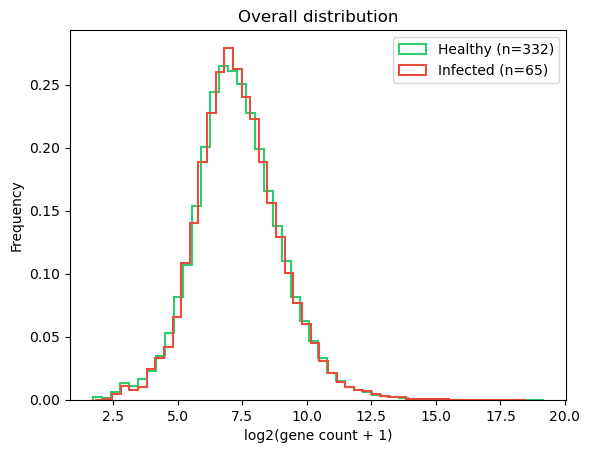

In [12]:
#5 plotting histogram after normalization

#What flatten() does: It takes your entire matrix (genes × samples) and unrolls it into one long array of all expression values.
#So instead of plotting each sample separately, you're plotting every single gene-expression value from all samples in that group
#The zero spike is genes that have zero expression across many samples,To remove it just filter them out before flattening.

healthy_vals = log2_cpm[Healthy_samples].values.flatten()
infected_vals = log2_cpm[Infected_samples].values.flatten()


plt.hist(healthy_vals[healthy_vals > 0], bins=50, color= '#2ecc71', 
         label=f'Healthy (n={len(Healthy_samples)})', density=True,
         histtype='step', linewidth=1.5)

plt.hist(infected_vals[infected_vals > 0], bins=50, color= '#e74c3c', 
         label=f'Infected (n={len(Infected_samples)})', density=True,
         histtype='step', linewidth=1.5)

plt.legend()
plt.title("Overall distribution")
plt.xlabel("log2(gene count + 1)")
plt.ylabel("Frequency")
plt.savefig("histogram_plot.png", dpi=300)
plt.show()

In [13]:
# Calculating the fold change
# Make sure all values are positive 

from scipy.stats import ttest_ind

healthy_mat  = log2_cpm[Healthy_samples] 
infected_mat = log2_cpm[Infected_samples] 

healthy_mean  = healthy_mat.mean(axis=1)
infected_mean = infected_mat.mean(axis=1)

fold_change   = infected_mean - healthy_mean
fold_change

A1BG          0.278481
A2M           0.147676
A2MP1         0.063285
AANAT         0.204556
ABCE1         0.057439
                ...   
ZSCAN21       0.018317
ZSCAN30       0.093475
ZSWIM4        0.600439
ZSWIM8        0.265617
ZSWIM8-AS1    0.112451
Length: 2738, dtype: float64

In [14]:
# Doing the differential expression statistical testing
# T-test for each gene (row)
t_stat, p_values = ttest_ind(infected_mat, healthy_mat, axis=1)
p_values


array([0.08609498, 0.44858963, 0.76084505, ..., 0.01822655, 0.08102192,
       0.39398641])

In [15]:
# Save the result in a DataFrame containing the fold change and p adjusted value
results = pd.DataFrame({'fold': fold_change, 'p_val': p_values})
results

,fold,p_val
A1BG,0.278481,0.086095
A2M,0.147676,0.448590
A2MP1,0.063285,0.760845
AANAT,0.204556,0.221663
ABCE1,0.057439,0.714363
...,...,...
ZSCAN21,0.018317,0.893386
ZSCAN30,0.093475,0.455403
ZSWIM4,0.600439,0.018227
ZSWIM8,0.265617,0.081022


In [16]:
res_deg = results[(results['p_val'] < 0.05) & (abs(results['fold']) > 0.4)]
print(res_deg.shape)
res_deg

(116, 2)


,fold,p_val
ACTG1,0.675266,0.045686
ADPGK,0.423788,0.003825
ANKRD12,0.500588,0.008980
APOBEC3B-AS1,0.433152,0.018377
APOBR,0.414209,0.016318
...,...,...
WDR86,0.544633,0.001514
YWHAZ,0.482621,0.031288
YY1,0.608194,0.001768
ZNRF2,0.460116,0.032161


In [17]:
DEG_20_ttst = res_deg.sort_values(by="p_val", ascending = True).head(20)
DEG_20_ttst

,fold,p_val
KLF13,0.942141,0.000035
DLG4,0.513189,0.000330
ARL4C,0.563456,0.000406
TYMP,0.588933,0.000419
RARA-AS1,0.504509,0.001149
PTP4A2,0.829294,0.001224
WDR86,0.544633,0.001514
CEBPD,0.591285,0.001537
MIR4665,0.593807,0.001633
YY1,0.608194,0.001768


In [18]:
DEG_20_ttst.to_csv(path + "\\DEG_20_ttst.csv")

In [19]:
top_deg_names = DEG_20_ttst.index
sample_names = log2_cpm.columns
print(log2_cpm.columns)

Index(['ZOQM06Q-1011', 'ZOBX723-1013', 'ZOBX723-1021', 'ZOBX723-1022',
       'ZO94RDZ-1011', 'ZO5QFNX-1012', 'ZO5QFNX-1013', 'ZNQOVZV-02',
       'ZNQOVZV-1011', 'ZNQOVZV-1012',
       ...
       'ZKFV71L-2011', 'ZKFV71L-6011', 'ZKFV71L-6021', 'ZK4CK8Y-07',
       'ZK4CK8Y-08', 'ZK4CK8Y-09', 'ZK4CK8Y-10', 'ZJXC41N-01', 'ZJXC41N-02',
       'ZJXC41N-11'],
      dtype='object', length=397)


In [20]:
print(meta["CL4"].unique())

['Infected' 'Healthy']


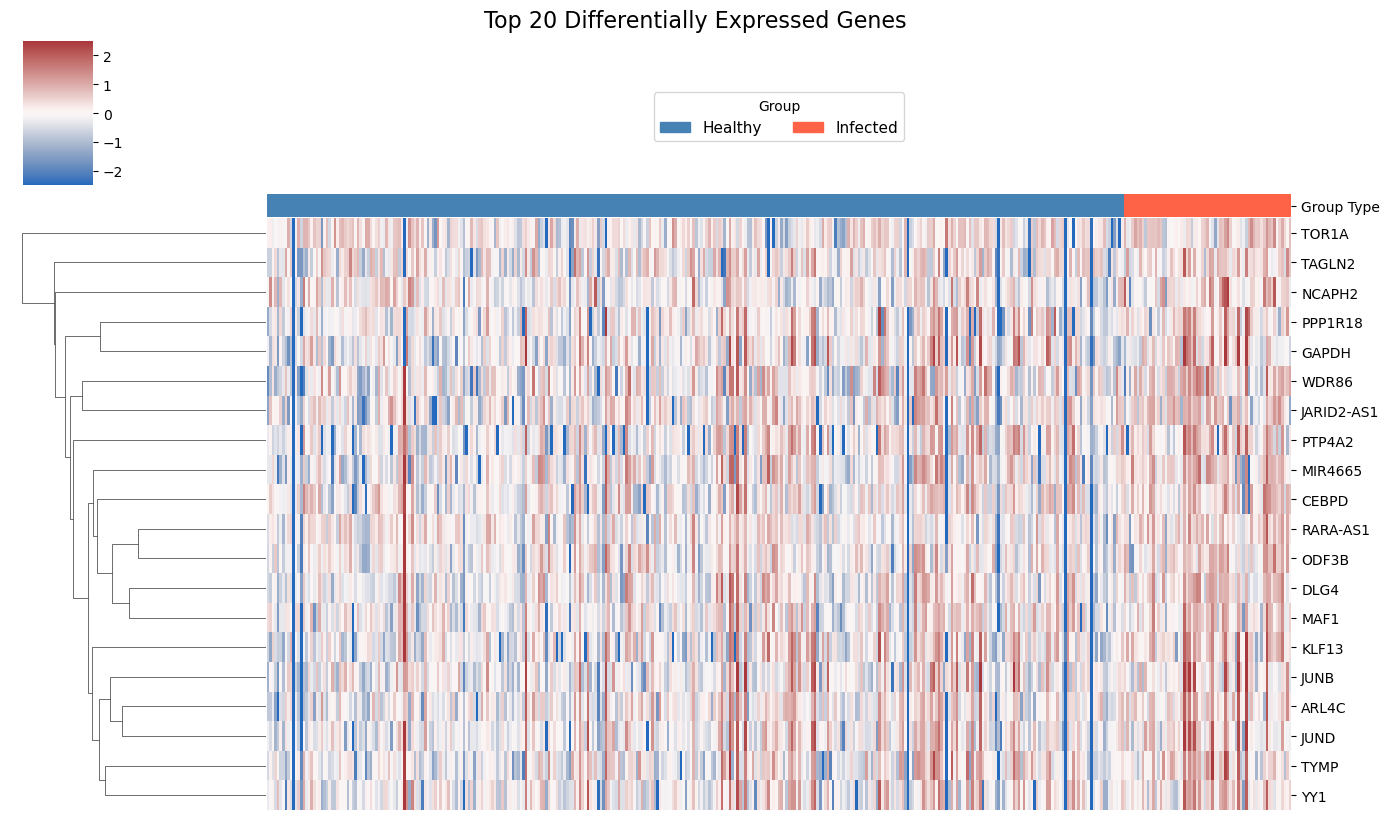

In [21]:
# Step 5: Heatmap of Top 20 DEGs
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

group_colors = {
    "Healthy"  : "steelblue",
    "Infected" : "tomato",
}

# Sort samples by group
meta_sorted = meta.sort_values("CL4")

# Subset top differentially expressed genes 
heatmap_scaled = log2_cpm.loc[top_deg_names]
heatmap_scaled = pd.DataFrame(
    zscore(heatmap_scaled, axis=1),
    index=heatmap_scaled.index,
    columns=heatmap_scaled.columns
)
heatmap_sorted = heatmap_scaled[meta_sorted.index]
col_colors_sorted = meta_sorted["CL4"].rename("Group Type").map(group_colors)

# Plot
g = sns.clustermap(
    heatmap_sorted,
    col_cluster=False,
    row_cluster=True,
    cmap="vlag",
    vmin=-2.5, vmax=2.5,
    col_colors=col_colors_sorted,
    figsize=(14, 8),
    yticklabels=True,
    xticklabels=False,
)
g.ax_col_dendrogram.legend(handles=[
    plt.Rectangle((0,0),1,1, color="steelblue", label="Healthy"),
    plt.Rectangle((0,0),1,1, color="tomato",    label="Infected")
], loc="center", ncol=2, fontsize=11, title="Group")


g.fig.suptitle("Top 20 Differentially Expressed Genes", y=1.02, fontsize=16)
g.fig.savefig("heatmap_top20_DEGs.png", dpi=300)
plt.show()